### Modules import

In [1]:
import os
import numpy as np
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt

### Dataset and model download & instantiation

In [2]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    """
    Create ImageNet validation DataLoader with required transforms.
    """
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=num_workers, 
        pin_memory=True             # faster data transfer to GPU
    )


def make_train_loader_cifar100(data_dir: str, 
                               batch_size: int = 256, 
                               num_workers: int = 4):
    """
    Create CIFAR-100 training DataLoader for fine-tuning with dataset-specific transforms.
    """
    transforms_train = transforms.Compose([
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

def make_val_loader_cifar100(data_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    """
    Create CIFAR-100 validation DataLoader with dataset-specific transforms.
    """
    transforms_val = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=False,
        download=True,
        transform=transforms_val
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

In [3]:
# dataset_dir_imagenet = "D:/imagenet"
dataset_dir_cifar100 = "D:/cifar100"
batch_size = 128  # takes 94% of RAM available on the laptop
num_workers = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device == torch.device("cuda"):
    print(torch.cuda.get_device_name())

NVIDIA GeForce GTX 1650


In [4]:
# 1. instantiate RegNetX_3.2GF with ImageNet1K weights
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
# regnetx_16 = models.regnet_x_16gf(weights=models.RegNet_X_16GF_Weights.DEFAULT, progress=True)
print("[V] Model instantiated")

[ ] Instantiating model...
[V] Model instantiated


In [5]:
print("[ ] Creating dataset...")
train_loader = make_train_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
val_loader = make_val_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
print("[V] Dataset created")

[ ] Creating dataset...
[V] Dataset created


### Model adaptation and fine-tuning

In [6]:
def adapt_model_cifar100(model):
    model.stem[0] = torch.nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    model.fc = torch.nn.Linear(regnetx_3_2.fc.in_features, 100)

In [8]:
def plot_metrics(trains: list, 
                 tests: list, 
                 epochs: int, 
                 metric_name: str = "metric",
                 graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i * len(trains)//len(tests) for i in range(len(tests))], 
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set_ylabel(metric_name)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()
    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))

In [ ]:
def finetuning(model: torch.nn.Module,
               train_loader: DataLoader, 
               test_loader: DataLoader,
               device: torch.device = torch.device("cpu"),
               epochs: int = 150):
    model.to(device)
    
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    best_acc = 0
    max_lr = 0.01 # 0.001
    weight_decay = 0.001 # 5e-4
    optimizer = AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    criterion = CrossEntropyLoss()
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

    checkpoint_dir = "checkpoints"
    graph_dir = f"graphs_{epochs}epochs"
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(graph_dir, exist_ok=True)
    
    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time()
        
        # training
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            train_losses.append(loss.item())
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        train_acc = 100. * correct / total
        train_accs.append(train_acc)
        
        # validation
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_losses.append(loss.item())
                
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        test_acc = 100. * correct / total
        test_accs.append(test_acc)
        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"regnet_cifar100_last_{epochs}epochs.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"regnet_cifar100_best_{epochs}epochs.pth"))
        
        epoch_time = time() - start_time
        print(f"Epoch: {epoch+1}/{epochs} | "
              f"Time: {epoch_time:.2f}s | "
              f"Train Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss/len(test_loader):.4f} | "
              f"Test Acc: {test_acc:.2f}% | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

    plot_metrics(train_losses, test_losses, epochs, metric_name="loss", graph_dir=graph_dir)
    plot_metrics(train_accs, test_accs, epochs, metric_name="acc", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")

In [ ]:
print("[ ] Adapting model layers for CIFAR-100...")
adapt_model_cifar100(regnetx_3_2)
print("[V] Model layers adapted for CIFAR-100")

[ ] Finetuning model on CIFAR-100...
Epoch 0 started...
Epoch: 1/100 | Time: 158.20s | Train Loss: 4.2479 | Train Acc: 5.02% | Test Loss: 3.9280 | Test Acc: 8.48% | LR: 0.009999
Epoch 1 started...
Epoch: 2/100 | Time: 157.62s | Train Loss: 3.6398 | Train Acc: 12.89% | Test Loss: 3.4460 | Test Acc: 17.46% | LR: 0.009998
Epoch 2 started...
Epoch: 3/100 | Time: 158.00s | Train Loss: 3.2414 | Train Acc: 19.87% | Test Loss: 5.3252 | Test Acc: 21.64% | LR: 0.009994
Epoch 3 started...
Epoch: 4/100 | Time: 156.67s | Train Loss: 3.0136 | Train Acc: 24.21% | Test Loss: 4.0294 | Test Acc: 28.77% | LR: 0.009990
Epoch 4 started...
Epoch: 5/100 | Time: 149.03s | Train Loss: 2.7458 | Train Acc: 29.95% | Test Loss: 3.0096 | Test Acc: 25.24% | LR: 0.009985
Epoch 5 started...
Epoch: 6/100 | Time: 152.77s | Train Loss: 2.6093 | Train Acc: 32.71% | Test Loss: 11.1427 | Test Acc: 10.08% | LR: 0.009978
Epoch 6 started...
Epoch: 7/100 | Time: 155.22s | Train Loss: 2.5878 | Train Acc: 33.22% | Test Loss: 3.06

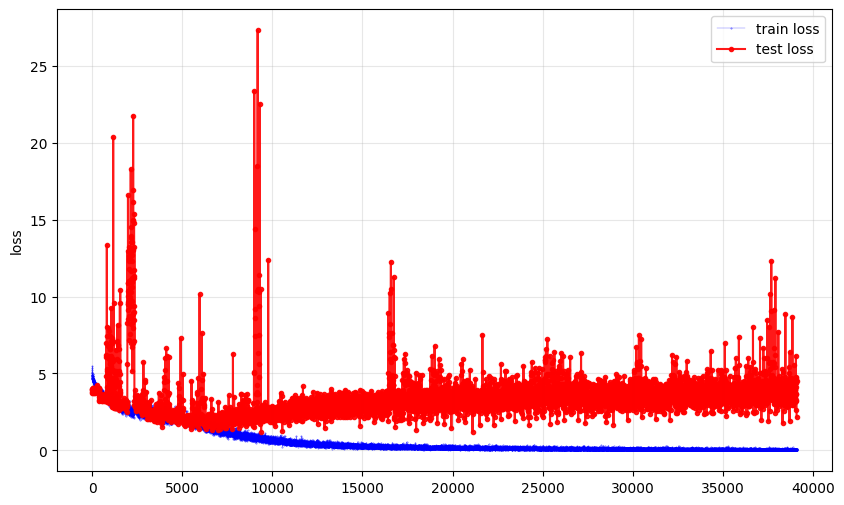

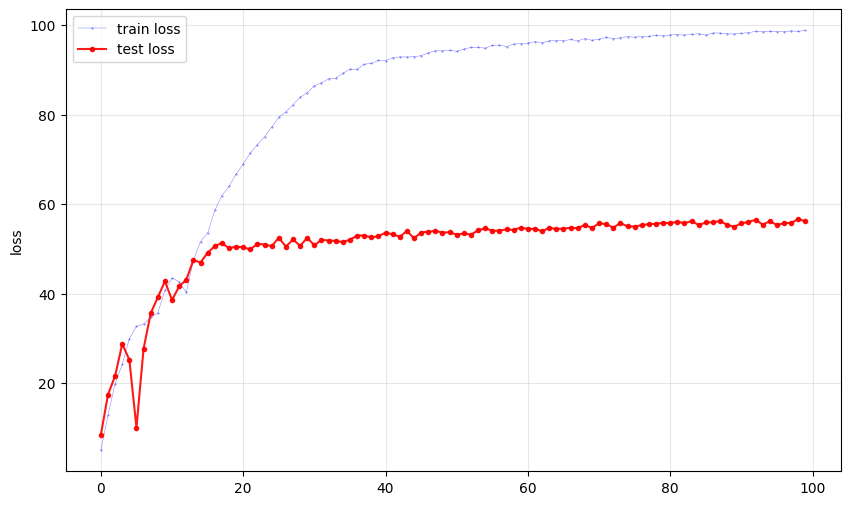

In [ ]:
print("[ ] Finetuning model on CIFAR-100...")
finetuning(regnetx_3_2, train_loader, val_loader, device, 150)
print("[V] Model finetuned on CIFAR-100")

### Main pipeline

In [7]:
checkpoint_path = "./checkpoints_100epochs/regnet_cifar100_best_100epochs.pth"
print("[ ] Loading checkpoints from path", checkpoint_path, "...")
checkpoint = torch.load(checkpoint_path)
print("[V] Checkpoints loaded")

print("[ ] Loading model fine-tuned for CIFAR-100...")
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded")

# optimizer = AdamW(regnetx_3_2.parameters())
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

n_epochs = checkpoint["epoch"]
best_accuracy = checkpoint["acc"]

[ ] Loading checkpoints from path ./checkpoints_100epochs/regnet_cifar100_best_100epochs.pth ...
[V] Checkpoints loaded
[ ] Loading model fine-tuned for CIFAR-100...
[V] Fine-tuned model loaded


In [8]:
seed = 42
torch.manual_seed(seed)

@torch.inference_mode()
def validate_top1_top5_time(model, 
                            loader: DataLoader, 
                            device: torch.device):
    """
    Runs validation and returns top-1 and top-5 accuracy percentages.
    """
    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0
    
    start_time = time()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)
        
    valid_time = time() - start_time

    return (top1_correct / total * 100,
            top5_correct / total * 100,
            valid_time)


def binarize_hook(module, input):
    """
    Forward-pre-hook for avgpool: replace input tensor by its sign (−1,0,+1).
    """
    x, = input
    # x_bin = 2 ** (x+1).log2().round() - 1                #-0.1%  for ResNet50 on CIFAR-10
    x_bin = 2 ** (x+1).log2().mul(2).round().mul(0.5) - 1  #-0.01% for ResNet50 on CIFAR-10
    # x_bin = x.sign() * torch.mean(x)
    return (x_bin,) 


def fuse_avgpool_linear(model, 
                        input_size: int):
    device = next(model.parameters()).device
    
    weights = model.fc.weight.data  # [100, 1008] for RegNetX_3_2 on CIFAR-100
    bias = model.fc.bias.data if (model.fc.bias is not None) else torch.zeros(weights.shape[0])
    
    with torch.no_grad():
        random_input = torch.randn(1, 3, input_size, input_size).to(device)
        features = model.stem(random_input)
        features = model.trunk_output(features)
        features = model.avgpool(features)  # shape = [batch, channels, H, W] = [1, 1008, 1, 1] for RegNetX_3_2 on CIFAR-100
        H, W = features.shape[-2:]
    
    divisor = H * W
    weights_fused = weights.repeat(1, divisor) / divisor
    
    return weights_fused.to(device), bias.to(device)


def mostleast_signific_classes(weights, 
                               feature_idx: int, 
                               dataloader: DataLoader, 
                               top_k: int = 5):
    class_weights = np.argsort(abs(weights[:, feature_idx]))
    class_names = dataloader.dataset.classes
    
    return {
        "top_classes_ids":        class_weights[-top_k:],
        "top_classes_names":      [class_names[class_id] for class_id in class_weights[-top_k:]],
        "top_classes_weights":    weights[class_weights[-top_k:]],
        "bottom_classes_ids":     class_weights[:top_k],
        "bottom_classes_names":   [class_names[class_id] for class_id in class_weights[:top_k]],
        "bottom_classes_weights": weights[class_weights[:top_k]]
    }

In [ ]:
def pipeline(model,
             val_loader: DataLoader, 
             device: torch.device = torch.device("cpu"),
             picture_size: int = 224,
             n_svd_components: int = 50):
    model.to(device)

    print("\n1.5. Validating model before binarizing:")
    top1_orig, top5_orig, val_time = validate_top1_top5_time(model, val_loader, device)
    print("    Top-1 Accuracy: ", top1_orig)
    print("    Top-5 Accuracy: ", top5_orig)
    print("    Validation time:", val_time)

    print("\n2. Binarizing features...")
    model.avgpool.register_forward_pre_hook(binarize_hook)

    print("\n2.5. Validating model after binarizing:")
    top1_bin, top5_bin, val_time = validate_top1_top5_time(model, val_loader, device)
    print(f"    Top-1 Accuracy: {top1_bin:.4f}, drop: {top1_orig - top1_bin}")
    print(f"    Top-5 Accuracy: {top5_bin:.4f}, drop: {top5_orig - top5_bin}")
    print("    Validation time:", val_time)

    print("\n3. Avgpool and linear layers fusing...")
    weights_fused, bias_fused = fuse_avgpool_linear(model, picture_size)
    print("Fused weight matrix shape:", weights_fused.shape)  # [100, 1008*H*W]

    print("\n4. SVD...")
    svd = TruncatedSVD(n_components=n_svd_components, random_state=seed)
    svd.fit(weights_fused.cpu().numpy())
    print("Explained variance ratio:", svd.explained_variance_ratio_.sum())

    print("\n5. Extracting binary features...")
    svd_components = svd.components_  # [n_svd_components, 1008*H*W]
    print()
    binary_features = (svd_components > 0).astype(int)
    print("Binary features:\n", binary_features)
    print("Binary features shape:", binary_features.shape)

    print("\n6. Counting significant features...")
    print("Number of significant binary features (> 0.1): ", np.sum(np.abs(svd_components) > 0.1))
    print("Number of significant binary features (> 0.25):", np.sum(np.abs(svd_components) > 0.25))
    
    print("\n8. Significant features semantics analysis:")
    top_classes = mostleast_signific_classes(weights_fused, 0, val_loader)
    

In [ ]:
print("[ ] Entering pipeline...\n\n")
pipeline(regnetx_3_2, val_loader, device)
# pipeline(regnetx_16, val_loader, device)
print("\n\n[V] Pipeline finished")

[ ] Entering pipeline...

3. Validating model before binarizing:
    Top-1 Accuracy: 56.18
    Top-5 Accuracy: 81.0

2. Binarizing features...

3. Validating model after binarizing:
    Top-1 Accuracy: 56.18
    Top-5 Accuracy: 81.0

4. Avgpool and linear layers fusing...
Fused weight matrix shape: torch.Size([100, 1008])

5. SVD...
Explained variance ratio: 0.750788

6. Extracting binary features...
Binary features:
 [[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [0 1 1 ... 0 0 1]
 ...
 [0 1 0 ... 0 0 1]
 [0 0 1 ... 1 1 0]
 [1 1 0 ... 1 0 0]]

7. Counting significant features...
Number of significant binary features: 1098
[V] Pipeline finished


### Add-on: SVD components search

In [9]:
def elbow_method_svd(X, components_set):
    metrics = {
        "n_significant_features_0.1": [],
        "n_significant_features_0.25": [],
        "n_significant_features_0.5": [],
        "explained_variances": [],
        "reconstruction_errors": [],
        "decomposition_time": []
    }
    
    for n_components in components_set:
        start_time = time()
        svd = TruncatedSVD(n_components=n_components, random_state=seed)
        X_reduced = svd.fit_transform(X)
        decomp_time = time() - start_time
        X_reconstructed = svd.inverse_transform(X_reduced)
        
        metrics["n_significant_features_0.1"].append(np.sum(np.abs(svd.components_) > 0.1))
        metrics["n_significant_features_0.25"].append(np.sum(np.abs(svd.components_) > 0.25))
        metrics["n_significant_features_0.5"].append(np.sum(np.abs(svd.components_) > 0.5))
        metrics["decomposition_time"].append(decomp_time)
        metrics["explained_variances"].append(svd.explained_variance_ratio_.sum())
        metrics["reconstruction_errors"].append(np.mean((X - X_reconstructed) ** 2))
    
    return metrics

In [10]:
regnetx_3_2.to(device)

print("\n1.5. Validating model before binarizing:")
top1_orig, top5_orig, val_time = validate_top1_top5_time(regnetx_3_2, val_loader, device)
print("    Top-1 Accuracy: ", top1_orig)
print("    Top-5 Accuracy: ", top5_orig)
print(f"    Validation time: {val_time:.2f} s")

print("\n2. Binarizing features...")
regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook)

print("\n2.5. Validating model after binarizing:")
top1_bin, top5_bin, val_time = validate_top1_top5_time(regnetx_3_2, val_loader, device)
print(f"    Top-1 Accuracy: {top1_bin:.4f}, drop: {top1_orig - top1_bin :.4f}")
print(f"    Top-5 Accuracy: {top5_bin:.4f}, drop: {top5_orig - top5_bin :.4f}")
print(f"    Validation time: {val_time:.2f} s")

print("\n3. Avgpool and linear layers fusing...")
weights_fused, bias_fused = fuse_avgpool_linear(regnetx_3_2, 32)
print("Fused weight matrix shape:", weights_fused.shape) 

print("\n3.5. Validating model after fusing:")
sd = regnetx_3_2.state_dict()
sd['fc.weight'] = weights_fused
sd['fc.bias'] = bias_fused
regnetx_3_2.load_state_dict(sd)
top1_fus, top5_fus, val_time = validate_top1_top5_time(regnetx_3_2, val_loader, device)
print(f"    Top-1 Accuracy: {top1_fus:.4f}, drop: {top1_bin - top1_fus :.4f}")
print(f"    Top-5 Accuracy: {top5_fus:.4f}, drop: {top5_bin - top5_fus :.4f}")
print(f"    Validation time: {val_time:.2f} s")


1.5. Validating model before binarizing:


    Top-1 Accuracy:  56.66
    Top-5 Accuracy:  81.19
    Validation time: 9.99 s

2. Binarizing features...

2.5. Validating model after binarizing:
    Top-1 Accuracy: 56.1800, drop: 0.4800
    Top-5 Accuracy: 81.0000, drop: 0.1900
    Validation time: 9.85 s

3. Avgpool and linear layers fusing...
Fused weight matrix shape: torch.Size([100, 1008])

3.5. Validating model after fusing:
    Top-1 Accuracy: 56.1800, drop: 0.0000
    Top-5 Accuracy: 81.0000, drop: 0.0000
    Validation time: 9.83 s


In [11]:
n_components_options = [i for i in range(5, 101, 5)]
metrics = elbow_method_svd(weights_fused.cpu().numpy(), n_components_options)

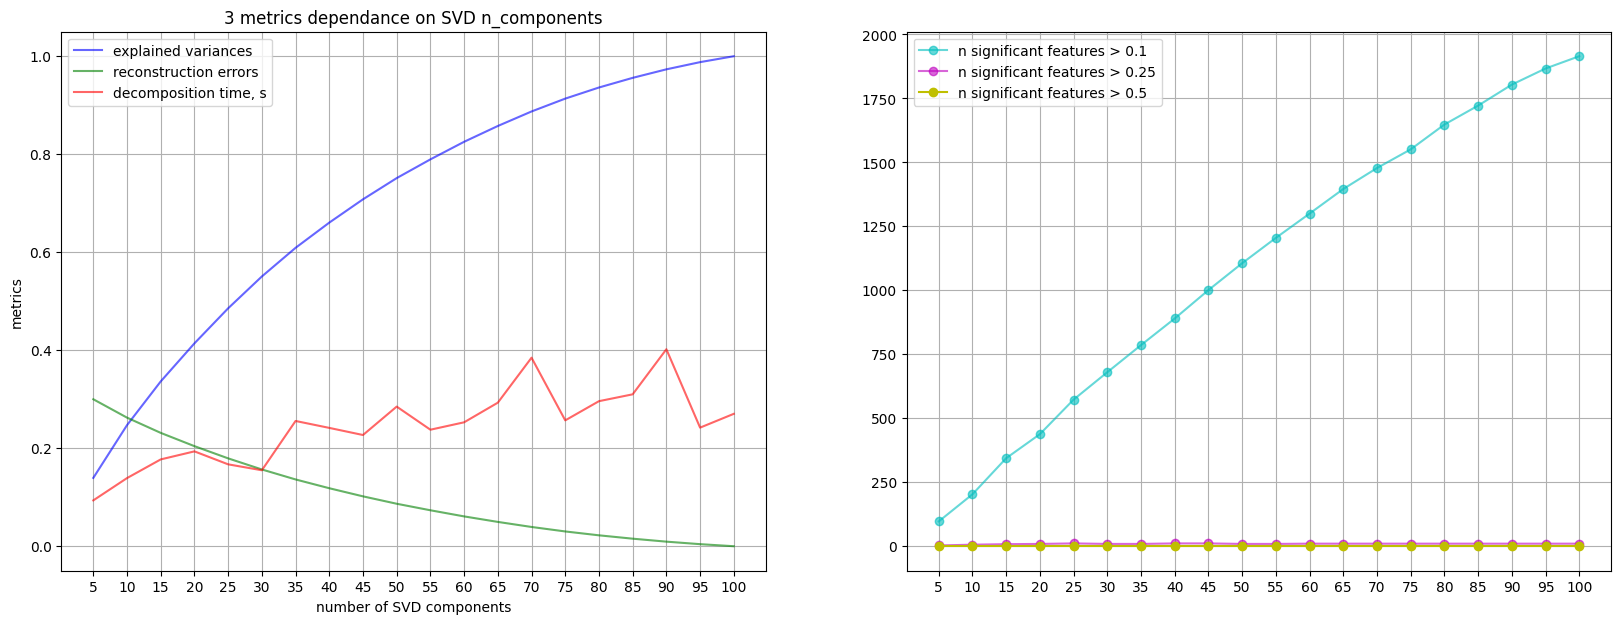

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(n_components_options, metrics["explained_variances"],   "b", alpha=0.6, label="explained variances")
axs[0].plot(n_components_options, metrics["reconstruction_errors"], "g", alpha=0.6, label="reconstruction errors")
axs[0].plot(n_components_options, metrics["decomposition_time"],    "r", alpha=0.6, label="decomposition time, s")

axs[0].set(
       xlabel="number of SVD components", 
       ylabel="metrics",
       title="3 metrics dependance on SVD n_components"
)
axs[0].set_xticks(n_components_options)
axs[0].grid(zorder=0)
axs[0].legend()


axs[1].plot(n_components_options, metrics["n_significant_features_0.1"],  "c-o", alpha=0.6, label="n significant features > 0.1")
axs[1].plot(n_components_options, metrics["n_significant_features_0.25"], "m-o", alpha=0.6, label="n significant features > 0.25")
axs[1].plot(n_components_options, metrics["n_significant_features_0.5"],  "y-o", label="n significant features > 0.5")

axs[1].set_xticks(n_components_options)
axs[1].grid(zorder=0)
axs[1].legend()

plt.show()

In [13]:
max_n_sign_features = max(metrics["n_significant_features_0.25"])

print("Number of largest sign.features >0.25: ", max_n_sign_features)
print("The n_components with this number:     ", [ n_components_options[i] for i in np.where(metrics["n_significant_features_0.25"] == max_n_sign_features)[0] ])

Number of largest sign.features >0.25:  11
The n_components with this number:      [25, 40, 45]


### Significant features' semantics analysis

In [14]:
top_classes_significance = mostleast_signific_classes(weights_fused.cpu().numpy(), 0, val_loader)
top_classes_significance["top_classes_ids"], top_classes_significance["top_classes_names"], \
top_classes_significance["bottom_classes_ids"], top_classes_significance["bottom_classes_names"]

(array([35, 69, 65, 93, 78]),
 ['girl', 'rocket', 'rabbit', 'turtle', 'snake'],
 array([87,  6, 91, 24, 37]),
 ['television', 'bee', 'trout', 'cockroach', 'house'])

In [15]:
def display_classes_examples(dataloader, classes_ids, n_examples: int=3):  
    classes_names = [dataloader.dataset.classes[class_id] for class_id in classes_ids]
    classes = {
        class_id: class_name
        for class_id, class_name in zip(classes_ids, classes_names)
    }
    images_to_show = []
    captions = []
    
    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            for image, label in zip(batch_images, batch_labels):
                label_num = label.item()
                if label_num in classes_ids:
                    class_name = classes[label_num]
                    if captions.count(class_name) < n_examples:
                        images_to_show.append(image)
                        captions.append(class_name)
            
            if all(captions.count(class_id) >= n_examples for class_id in classes_ids):
                break
    
    fig, axes = plt.subplots(
        len(classes_ids), 
        n_examples, 
        figsize=(n_examples * 2, len(classes_names) * 2)
    )
    
    for i, class_name in enumerate(classes_names):
        indices = [id for id, caption in enumerate(captions) if (caption == class_name)][:n_examples]
        
        for j, idx in enumerate(indices):
            ax = axes[i][j]
            image = images_to_show[idx].numpy().transpose(1, 2, 0)
            
            mean = [0.5071, 0.4867, 0.4408]
            std = [0.2675, 0.2565, 0.2761]
            image = std * image + mean
            image = np.clip(image, 0, 1)
            
            ax.imshow(image)
            ax.set_xticks([])
            ax.set_yticks([])
            
            if j == 0:
                ax.set_ylabel(class_name, rotation=0, ha='right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

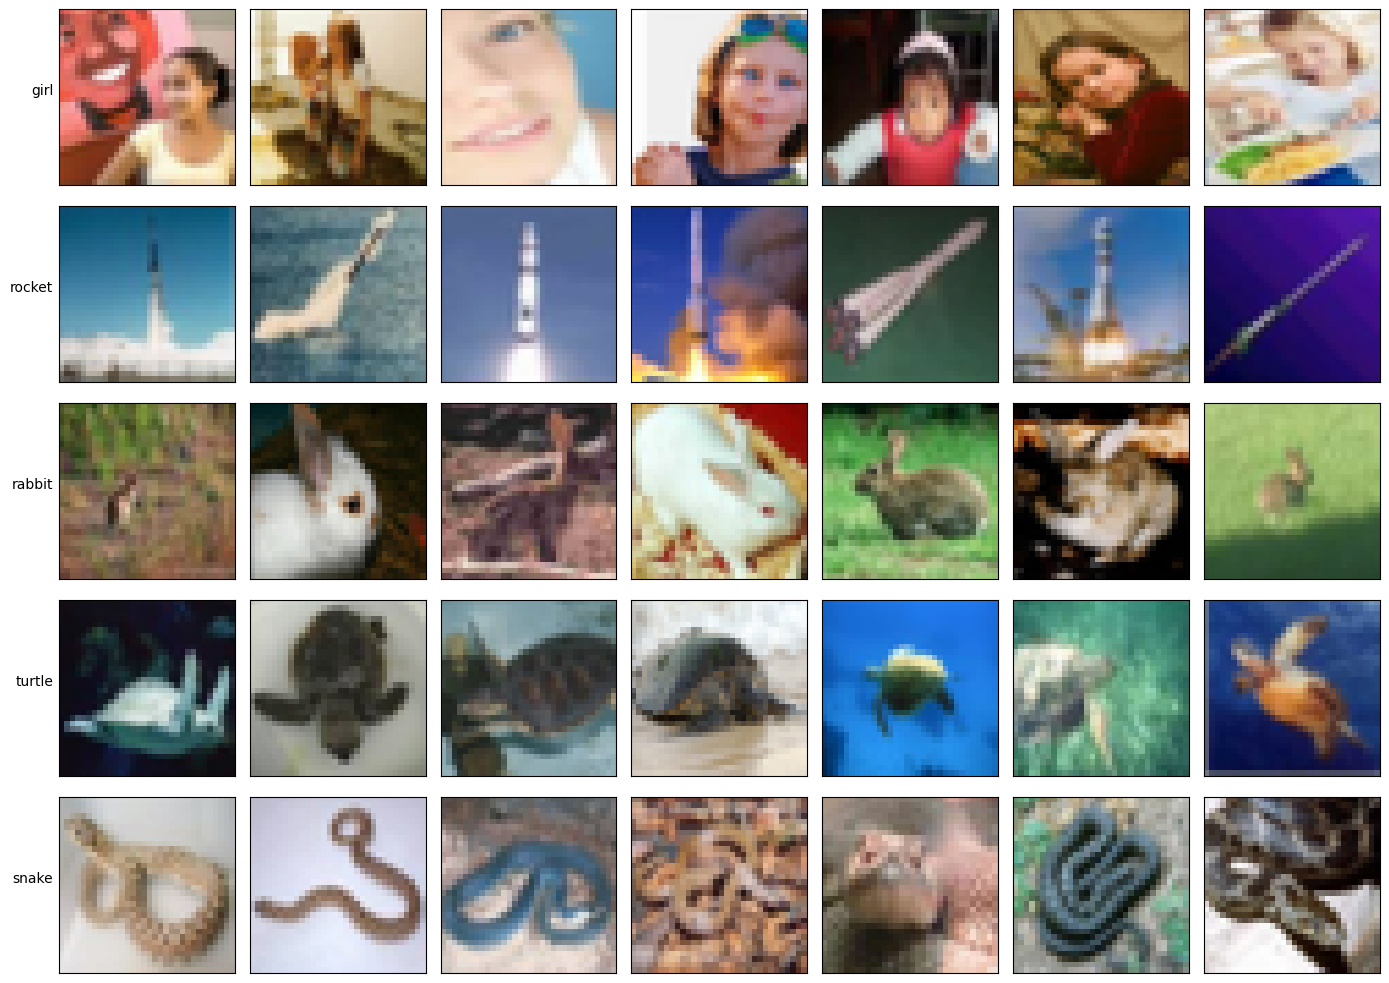

In [18]:
display_classes_examples(val_loader, top_classes_significance["top_classes_ids"], 7)

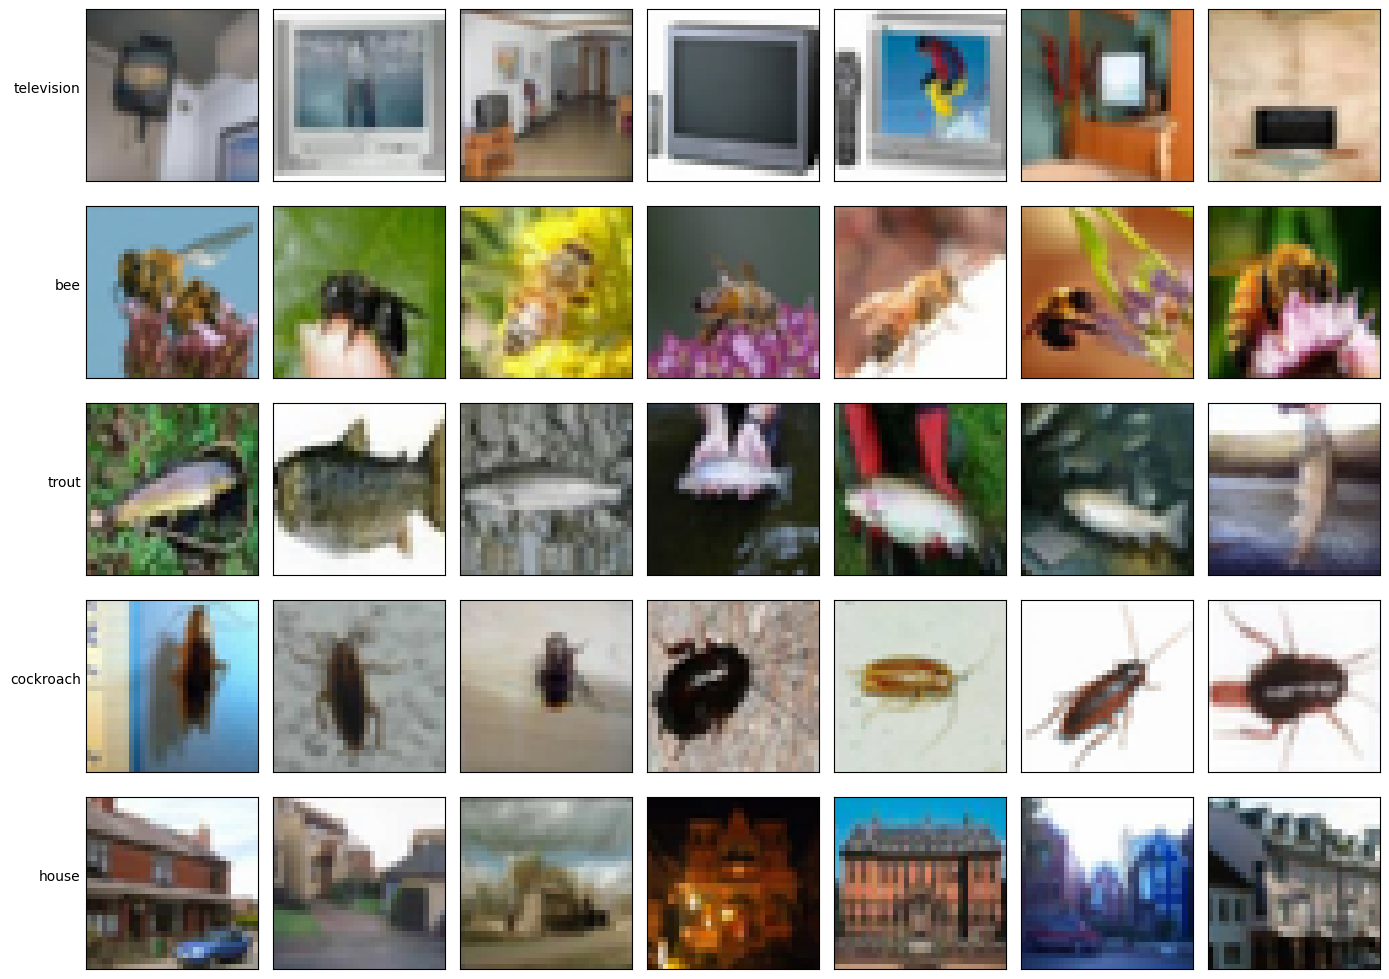

In [19]:
display_classes_examples(val_loader, top_classes_significance["bottom_classes_ids"], 7)